In [2]:
"""
Utility functions for regime detection analysis
"""
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def calculate_rolling_stats(series, window=24, prefix=''):
    """Calculate rolling statistics for a stationary series"""
    rolling_stats = pd.DataFrame(index=series.index)

    # Basic statistics with period in name (for stationary series)
    rolling_stats[f'{prefix}_{window}_std'] = series.rolling(window, min_periods=1).std()
    rolling_stats[f'{prefix}_{window}_kurt'] = series.rolling(window, min_periods=4).apply(
        lambda x: x.kurt() if len(x) >= 4 else 0)
    rolling_stats[f'{prefix}_{window}_skew'] = series.rolling(window, min_periods=3).apply(
        lambda x: x.skew() if len(x) >= 3 else 0)

    return rolling_stats

def calculate_sma_distance(series, window=24, prefix=''):
    """Calculate distance to SMA for a non-stationary series (price)"""
    sma = series.rolling(window, min_periods=1).mean()
    dist_sma = pd.DataFrame(index=series.index)
    dist_sma[f'{prefix}_{window}_dist_sma'] = (series - sma) / sma * 100
    return dist_sma

def visualize_split(train_size, test_size):
    total = train_size + test_size
    train_pct = int(train_size / total * 50)  # 50 chars wide
    test_pct = int(test_size / total * 50)

    # ANSI color codes
    BLUE = '\033[94m'
    ORANGE = '\033[38;5;208m'
    RESET = '\033[0m'

    print("Dataset Split Visualization")
    print("=" * 52)
    print(f"Train: {BLUE}{'█' * train_pct}{'░' * test_pct}{RESET} {train_size} samples ({train_size/total*100:.0f}%)")
    print(f"Test:  {ORANGE}{'░' * train_pct}{'█' * test_pct}{RESET} {test_size} samples ({test_size/total*100:.0f}%)")
    print("=" * 52)


  
def plot_feature_grid(df, cols_per_row=3, figsize_per_plot=(5, 3),
                     line_color='cyan', text_color='white',
                     background_color=None, title_prefix='',
                     show_grid=False, tight_layout=True):
    """
    Create a grid of subplots for exploratory data analysis of features.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with features to plot. Should have a MultiIndex with 'timestamp' level
        or a regular index that will be used as x-axis
    cols_per_row : int
        Number of columns per row in the subplot grid (default 3)
    figsize_per_plot : tuple
        Figure size per individual plot (width, height) in inches (default (5, 3))
    line_color : str
        Color for the plot lines (default 'cyan')
    text_color : str
        Color for text, labels, and spines (default 'white')
    background_color : str or None
        Background color for the figure (default None, which uses default background)
    title_prefix : str
        Optional prefix to add to the figure title (default '')
    show_grid : bool
        Whether to show gridlines on plots (default False)
    tight_layout : bool
        Whether to apply tight layout to prevent overlap (default True)

    Returns:
    --------
    fig, axes : tuple
        The matplotlib figure and axes objects for further customization

    """

    # Handle index - check if it's MultiIndex with timestamp level
    if isinstance(df.index, pd.MultiIndex):
        if 'timestamp' in df.index.names:
            timestamps = df.index.get_level_values('timestamp')
        else:
            # Use the first level if no timestamp level exists
            timestamps = df.index.get_level_values(0)
    else:
        # Use regular index
        timestamps = df.index

    # Calculate grid dimensions
    n_features = len(df.columns)
    n_rows = int(np.ceil(n_features / cols_per_row))

    # Calculate total figure size
    fig_width = figsize_per_plot[0] * cols_per_row
    fig_height = figsize_per_plot[1] * n_rows

    # Create subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=cols_per_row,
                            figsize=(fig_width, fig_height))

    # Set background color if specified
    if background_color:
        fig.patch.set_facecolor(background_color)

    # Add title if prefix is provided
    if title_prefix:
        fig.suptitle(f'{title_prefix}Feature Analysis Grid',
                    fontsize=16, color=text_color, y=1.02)

    # Flatten axes array for easier iteration
    # Handle case where there's only one subplot
    if n_features == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()

    # Plot each feature
    for i, col in enumerate(df.columns):
        ax = axes[i]

        # Plot the data
        ax.plot(timestamps, df[col], color=line_color, linewidth=0.8)

        # Set title
        ax.set_title(col, color=text_color, fontsize=10, pad=5)

        # Style the axes
        ax.tick_params(colors=text_color, labelsize=8)

        # Set spine colors
        for spine in ['bottom', 'top', 'right', 'left']:
            ax.spines[spine].set_color(text_color)

        # Optional grid
        if show_grid:
            ax.grid(True, alpha=0.2, color=text_color, linestyle='--')

        # Set background color for each subplot if specified
        if background_color:
            ax.set_facecolor(background_color)

        # Rotate x-axis labels if they're dates
        if hasattr(timestamps, 'dtype') and np.issubdtype(timestamps.dtype, np.datetime64):
            ax.tick_params(axis='x', rotation=45)

        # Format y-axis for better readability
        ax.yaxis.get_major_formatter().set_scientific(False)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        if j < len(axes):
            axes[j].set_visible(False)

    # Apply tight layout if requested
    if tight_layout:
        plt.tight_layout()

    # Show the plot
    plt.show()

    return

def plot_regime_clusters(df, train_size=0.75, colormap='Set1', figsize=(1000, 600)):
    """
    Create an interactive Bokeh plot showing S&P500 prices colored by regime clusters
    with train/test split visualization.
    """
    from bokeh.models import ColumnDataSource
    import matplotlib.colors as mcolors

    # 1. Prepare necessary columns
    cols_to_copy = ['close', 'cluster']
    if 'confidence' in df.columns:
        cols_to_copy.append('confidence')

    viz_df = df[cols_to_copy].copy()
    viz_df = viz_df.dropna(subset=['cluster'])
    viz_df['cluster_str'] = viz_df['cluster'].astype(int).astype(str)

    
    viz_df = viz_df.reset_index()
    # yfinance names the index 'Date' or 'Datetime' depending on frequency
    date_col = viz_df.columns[0]          # first column = old index
    viz_df = viz_df.rename(columns={date_col: 'timestamp'})

    # 2. Calculate split
    split_index = int(len(viz_df) * train_size)
    split_timestamp = viz_df.iloc[split_index]['timestamp']
    print(f" Train/Test split at: {split_timestamp}")
    print(f"   Training data: {split_index:,} samples")
    print(f"   Test data: {len(viz_df) - split_index:,} samples")

    # 3. Color palette
    n_clusters = viz_df['cluster_str'].nunique()
    print(f" Number of unique clusters detected: {n_clusters}")

    cmap = plt.cm.get_cmap(colormap)
    colors = [mcolors.to_hex(cmap(i / max(n_clusters - 1, 1))) for i in range(n_clusters)]
    cluster_ids = sorted(viz_df['cluster_str'].unique())
    color_mapping = {str(c): colors[i] for i, c in enumerate(cluster_ids)}
    viz_df['color'] = viz_df['cluster_str'].map(color_mapping)
    print(f" Color mapping: {color_mapping}")

    # 4. Create figure
    p = figure(
        width=figsize[0],
        height=figsize[1],
        title="S&P 500 Spot Price with Gaussian Mixture Regime Detection (Train/Test Split)",
        x_axis_type="datetime",
        x_axis_label="Time",
        y_axis_label="Close Price (USD)",
        tools="pan,wheel_zoom,box_zoom,reset,save",
        toolbar_location="above"
    )

    # Dark style
    p.background_fill_color = "#1a1a1a"
    p.border_fill_color = "#1a1a1a"
    p.outline_line_color = "#333333"
    p.grid.grid_line_color = "#3a3a3a"
    p.grid.grid_line_alpha = 0.3
    p.xaxis.axis_label_text_color = "#c0c0c0"
    p.yaxis.axis_label_text_color = "#c0c0c0"
    p.xaxis.major_label_text_color = "#a0a0a0"
    p.yaxis.major_label_text_color = "#a0a0a0"
    p.xaxis.axis_line_color = "#505050"
    p.yaxis.axis_line_color = "#505050"
    p.xaxis.major_tick_line_color = "#505050"
    p.yaxis.major_tick_line_color = "#505050"
    p.title.text_color = "#e0e0e0"
    p.title.text_font_size = "16pt"

    # 5. Scatter by cluster
    for cluster_id in cluster_ids:
        cluster_data_df = viz_df[viz_df['cluster_str'] == cluster_id].copy()

        if 'confidence' in viz_df.columns:
            cluster_data_df['size'] = (cluster_data_df['confidence'] * 5).clip(lower=2)
        else:
            cluster_data_df['size'] = 5

        cluster_data = ColumnDataSource(cluster_data_df)

        p.scatter(
            x='timestamp',
            y='close',
            source=cluster_data,
            size='size',          
            color=color_mapping[cluster_id],
            alpha=0.7,
            legend_label=f"Cluster {cluster_id}",
            name=f"cluster_{cluster_id}"
        )

    # 6. Train/test separation line
    train_test_line = Span(
        location=split_timestamp,
        dimension='height',
        line_color='white',
        line_dash='dashed',
        line_width=2,
        line_alpha=0.6
    )
    p.add_layout(train_test_line)

    # Train / test labels
    train_label_x = viz_df.iloc[split_index // 2]['timestamp']
    test_label_x = viz_df.iloc[split_index + (len(viz_df) - split_index) // 2]['timestamp']
    label_y = viz_df['close'].max() * 0.95

    p.add_layout(Label(
        x=train_label_x, y=label_y,
        text=f'TRAINING DATA ({int(train_size*100)}%)',
        text_color='#00D9FF', text_font_size='12pt',
        text_font_style='bold', text_alpha=0.7,
        x_units='data', y_units='data'
    ))
    p.add_layout(Label(
        x=test_label_x, y=label_y,
        text=f'TEST DATA ({int((1-train_size)*100)}%)',
        text_color='#FF6B6B', text_font_size='12pt',
        text_font_style='bold', text_alpha=0.7,
        x_units='data', y_units='data'
    ))

    # 7. Hover tool
    tooltips = [
        ("Date",    "@timestamp{%Y-%m-%d}"),
        ("Price",   "@close{$0,0.00}"),
        ("Cluster", "@cluster_str"),
    ]
    if 'confidence' in viz_df.columns:
        tooltips.append(("Confidence", "@confidence{0.000}"))

    hover = HoverTool(tooltips=tooltips, formatters={'@timestamp': 'datetime'})
    p.add_tools(hover)

    # 8. Legend & axes
    p.legend.location = "top_left"
    p.legend.click_policy = "hide"
    p.legend.label_text_color = "#c0c0c0"
    p.legend.background_fill_color = "#2a2a2a"
    p.legend.background_fill_alpha = 0.8
    p.legend.border_line_color = "#505050"

    p.xaxis.formatter = DatetimeTickFormatter(
        hours="%H:%M", days="%Y-%m-%d", months="%Y-%m", years="%Y"
    )

    # 9. Display
    try:
        get_ipython()
        output_notebook()
        curdoc().theme = 'dark_minimal'
    except NameError:
        pass

    show(p)
    return p

In [3]:
# Imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import norm

# Visualization with Bokeh
from bokeh.plotting import figure, output_notebook, show
from bokeh.layouts import column, row, gridplot
from bokeh.models import HoverTool, DatetimeTickFormatter
from bokeh.io import curdoc
from bokeh.themes import Theme
import bokeh.palettes as bp


plt.style.use('dark_background')

output_notebook()

curdoc().theme = 'dark_minimal'

#--------------------------------------------------------------------------------

Loading BokehJS ...

In [4]:
import yfinance as yf

# 1. Download raw Data

ticker = "^GSPC"
 
df = yf.download(
    ticker,
    start="2000-01-01",
    end="2025-12-31",
    auto_adjust=True,   # Adjusted prices for splits/dividends
    progress=True,
)
 

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
 
# Columns renaming 
df = df.rename(columns={
    "Open":   "open",
    "High":   "high",
    "Low":    "low",
    "Close":  "close",
    "Volume": "volume",
})

df.tail()


[*********************100%***********************]  1 of 1 completed


Price,close,high,low,open,volume
Date,,,,,
2025-12-23,6909.790039,6910.879883,6868.810059,6872.410156,3820560000
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000
2025-12-30,6896.240234,6913.250000,6893.470215,6900.439941,3309930000


<Axes: xlabel='Date'>

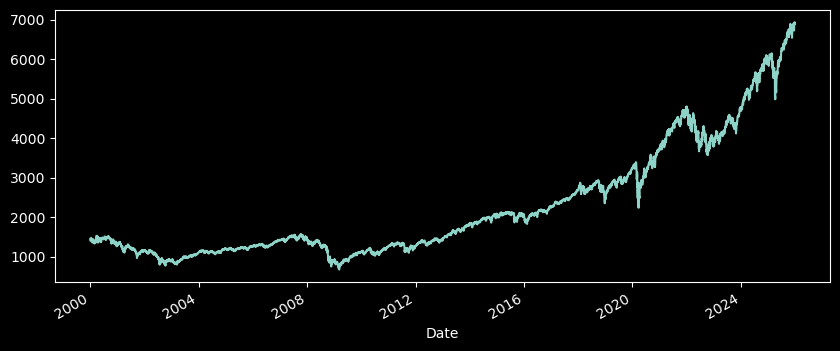

In [5]:


df.close.plot(figsize=(10,4))



In [6]:
# Calcul of Log-Return

df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

In [7]:
# Windows initialization
window_list = [10,50]

# Rolling stats for all windows
feature_list = []

# Features Creation
for window in window_list:
    feature_list.append(calculate_rolling_stats(df['log_returns'], window=window, prefix='fut_ret'))
    feature_list.append(calculate_sma_distance(df['close'], window=window, prefix='fut'))

features = pd.concat(feature_list, axis=1)

# Delete NaN (due to rolling window)
features = features.dropna()

In [8]:


features.head()



,fut_ret_10_std,fut_ret_10_kurt,fut_ret_10_skew,fut_10_dist_sma,fut_ret_50_std,fut_ret_50_kurt,fut_ret_50_skew,fut_50_dist_sma
Date,,,,,,,,
2000-01-07,0.027235,1.870186,-0.817339,1.488100,0.027235,1.870186,-0.817339,1.488100
2000-01-10,0.024347,2.372308,-1.201380,2.176937,0.024347,2.372308,-1.201380,2.176937
2000-01-11,0.022461,0.982773,-0.714755,0.721061,0.022461,0.982773,-0.714755,0.721061
2000-01-12,0.020525,1.419165,-0.656492,0.244268,0.020525,1.419165,-0.656492,0.244268
2000-01-13,0.019670,1.609538,-0.901055,1.299407,0.019670,1.609538,-0.901055,1.299407


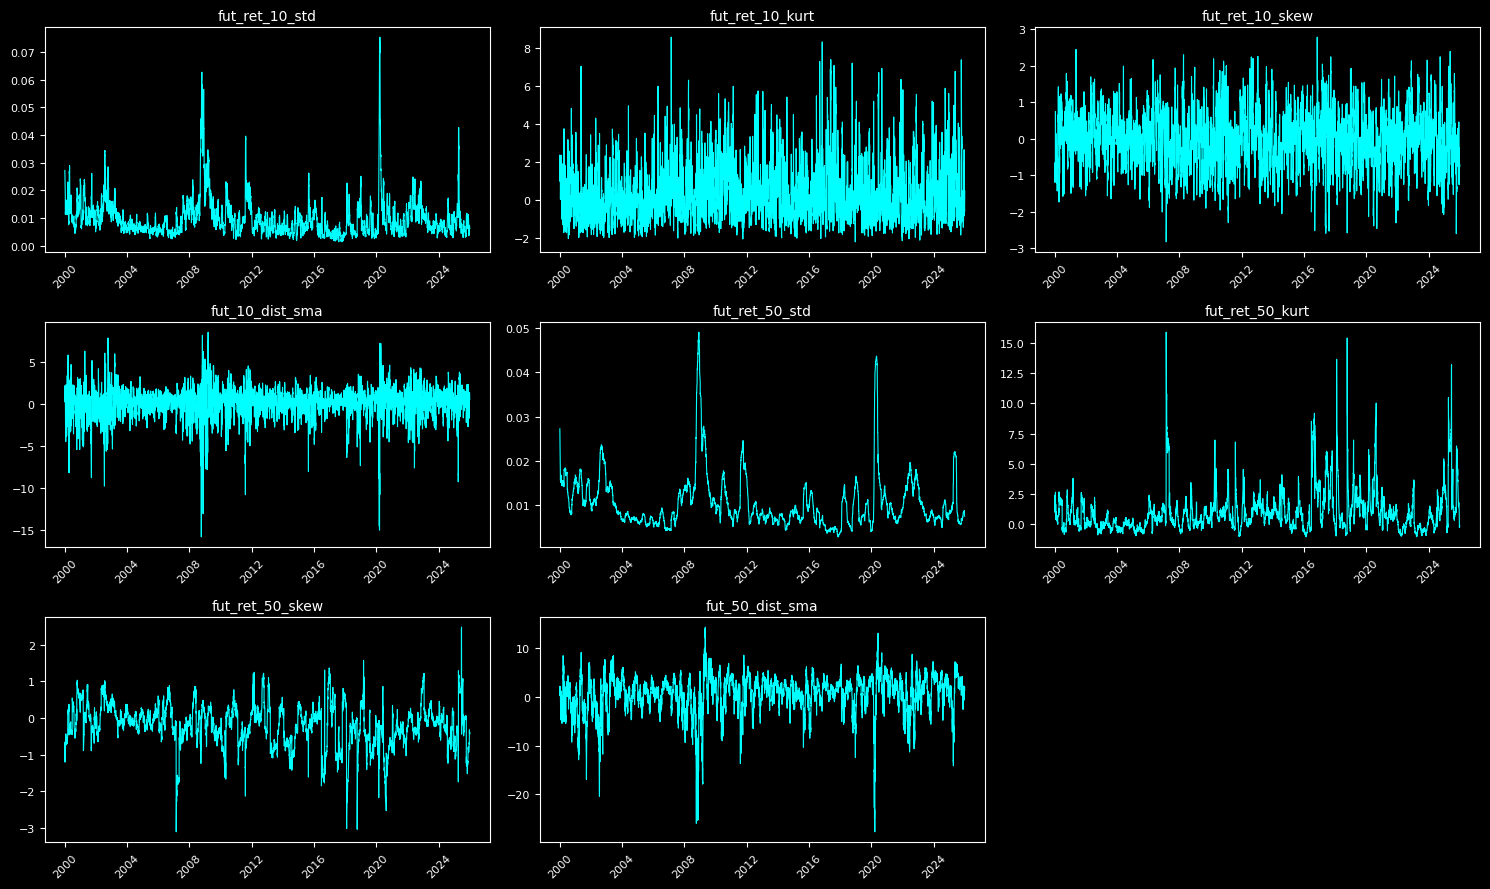

In [9]:


plot_feature_grid(features)



In [10]:
TRAIN_SIZE = 0.70  # 70% for training

X_train, X_test = train_test_split(features, train_size=TRAIN_SIZE, shuffle=False)

# Warning for shuffle !

In [11]:

visualize_split(train_size=X_train.shape[0], test_size=X_test.shape[0])


Dataset Split Visualization
Train: ██████████████████████████████████░░░░░░░░░░░░░░░ 4573 samples (70%)
Test:  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░███████████████ 1961 samples (30%)


In [12]:
# Scaling with the standard scaler (Z-score)
scaler = StandardScaler().set_output(transform="pandas")

# Fit on TRAIN data only to avoid overfitting and Data leakage
scaler.fit(X_train)

# Transform on TRAIN and TEST
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test) 

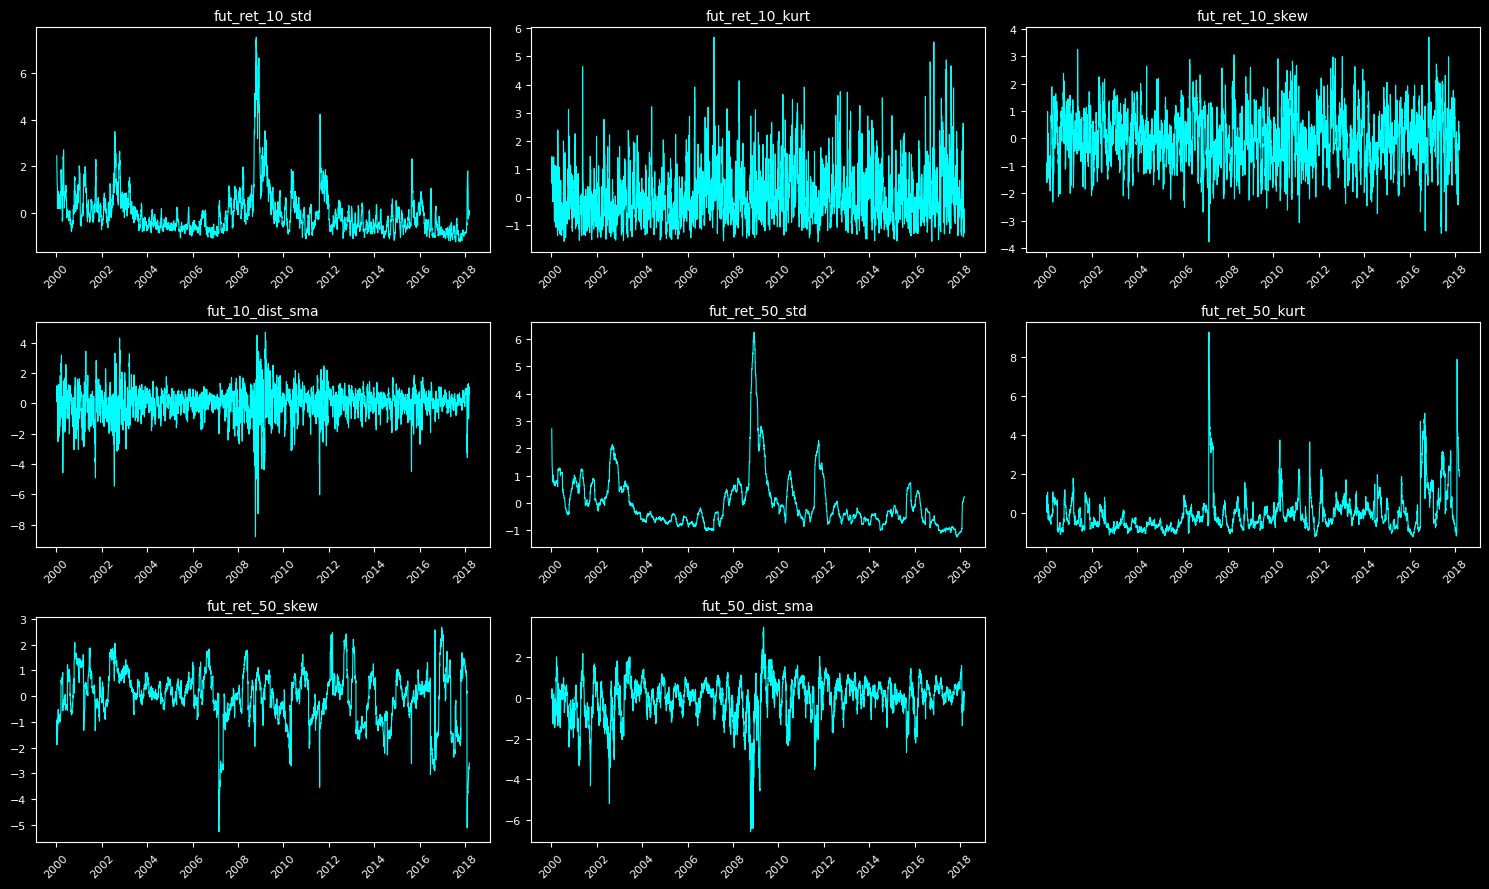

In [13]:
# New features

plot_feature_grid(X_train_scaled)



In [14]:
# Number of clusters 
N_CLUSTERS = 3  # Bull, Bear, Flat

# GMM creation
model = GaussianMixture(n_components=N_CLUSTERS, random_state=44)

# Trainning on the train set 
model.fit(X_train_scaled)

# Predict clusters
train_clusters = model.predict(X_train_scaled)
test_clusters = model.predict(X_test_scaled)

# Calcul of  posterior probabilities with predict_proba
train_proba = model.predict_proba(X_train_scaled)
test_proba = model.predict_proba(X_test_scaled)
print("Example. Membership Probability  (train) :\n", train_proba[:3])

# Confidence = proba max
train_confidence = train_proba.max(axis=1)  # [0, 1]
test_confidence = test_proba.max(axis=1)    # [0, 1]

Example. Membership Probability  (train) :
 [[1.54784038e-09 9.99999998e-01 7.25502531e-42]
 [2.45247223e-08 9.99999975e-01 9.28700757e-26]
 [2.11220841e-04 9.99788779e-01 1.04811537e-23]]


In [15]:
#  Improve of the Data Frame

df.loc[X_train.index, 'cluster'] = train_clusters
df.loc[X_test.index, 'cluster'] = test_clusters

df.loc[X_train.index, 'confidence'] = train_confidence
df.loc[X_test.index, 'confidence'] = test_confidence


df.dropna(inplace=True)
df.head()



Price,close,high,low,open,volume,log_returns,cluster,confidence
Date,,,,,,,,
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,0.026730,1.0,1.000000
2000-01-10,1457.599976,1464.359985,1441.469971,1441.469971,1064800000,0.011128,1.0,1.000000
2000-01-11,1438.560059,1458.660034,1434.420044,1457.599976,1014000000,-0.013149,1.0,0.999789
2000-01-12,1432.250000,1442.599976,1427.079956,1438.560059,974600000,-0.004396,1.0,0.997222
2000-01-13,1449.680054,1454.199951,1432.250000,1432.250000,1030400000,0.012096,1.0,0.997724


In [16]:
df.cluster.value_counts(normalize=True)

cluster
0.0    0.588766
2.0    0.217478
1.0    0.193756
Name: proportion, dtype: float64

In [17]:


plot_regime_clusters(df=df, train_size=0.70, figsize=(1200, 800))



 Train/Test split at: 2018-03-14 00:00:00
   Training data: 4,573 samples
   Test data: 1,961 samples
 Number of unique clusters detected: 3
 Color mapping: {'0': '#e41a1c', '1': '#ff7f00', '2': '#999999'}


NameError: name 'Span' is not defined

In [ ]:
#  STRATEGY SETUP
#  Generating entry/exit signals from GMM regimes


# PARAMETERS
INIT_CASH    = 100_000
FEES         = 0.001
TRAIN_SIZE   = 0.70

BEAR_CONFIRM = 5     # 1 consecutive trading week in BEAR regime
MAX_LOSS  = 0.05  # exit if price < ATH × (1 - 5%)
REENTRY_WAIT = 25    # 1 calendar month before re-entry


# 1. TRAIN / TEST SPLIT

n_train  = int(len(df) * TRAIN_SIZE)
train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

print(f" Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train_df):,} days)")
print(f" Test  : {test_df.index[0].date()} → {test_df.index[-1].date()}  ({len(test_df):,} days)")


# 2. IDENTIFY BULL / BEAR / NEUTRAL

def identify_clusters(df: pd.DataFrame) -> dict:
    stats   = df.groupby('cluster')['log_returns'].mean().sort_values()
    ids     = stats.index.tolist()
    mapping = {}
    for i, cid in enumerate(ids):
        if i == 0:            mapping[cid] = 'bear'
        elif i == len(ids)-1: mapping[cid] = 'bull'
        else:                 mapping[cid] = 'neutral'
    print("\n📊 Automatic regime identification:")
    icons = {'bull': '📈', 'bear': '📉', 'neutral': '➡️'}
    for cid, regime in mapping.items():
        mean = stats[cid] * 100
        print(f"   Cluster {int(cid)} → {icons[regime]}  {regime.upper():<8}  "
              f"avg return = {mean:+.4f} %/day")
    return mapping

cluster_map = identify_clusters(df)


# 3. SIGNAL GENERATION (on the test set)

#   EXIT   if bear_streak >= BEAR_CONFIRM AND price < ATH × (1 - MAX_LOSS)
#   ENTRY  if regime != BEAR AND days_out >= REENTRY_WAIT

def generate_signals(df: pd.DataFrame, cluster_map: dict) -> pd.DataFrame:
    closes      = df['close'].values
    regimes_raw = np.array([cluster_map.get(c, 'neutral') for c in df['cluster'].values])
    n           = len(df)

    entries  = np.zeros(n, dtype=bool)
    exits    = np.zeros(n, dtype=bool)
    regimes  = np.empty(n, dtype=object)
    ath_arr  = np.zeros(n)
    dd_arr   = np.zeros(n)

    ath_price   = 0.0
    bear_streak = 0
    in_position = False
    days_out    = REENTRY_WAIT 

    for i in range(n):
        c      = closes[i]
        regime = regimes_raw[i]

        ath_price = max(ath_price, c)

        if regime == 'bear':
            bear_streak += 1
        else:
            bear_streak = 0

        if not in_position:
            days_out += 1

        dd_current   = (c / ath_price) - 1
        bear_signal  = bear_streak >= BEAR_CONFIRM
        crash_signal = dd_current  <= -MAX_LOSS

        if i == 0:
            entries[i] = True
            in_position = True
            days_out = 0
            ath_price = c
        else:
            if in_position and bear_signal and crash_signal:
                exits[i]    = True
                in_position = False

            elif not in_position and regime != 'bear' and days_out >= REENTRY_WAIT:
                entries[i]  = True
                in_position = True
                days_out    = 0

        regimes[i] = regime
        ath_arr[i] = ath_price
        dd_arr[i]  = round(dd_current * 100, 2)

    signals = df.copy()
    signals['regime']   = regimes
    signals['ath']      = ath_arr
    signals['dd_ath']   = dd_arr
    signals['entry']    = entries
    signals['exit']     = exits
    signals['position'] = 0

    # Reconstruct the position column (1 = in position, 0 = flat)
    pos = 0
    for i in range(n):
        if signals['entry'].iloc[i]: pos = 1
        if signals['exit'].iloc[i]:  pos = 0
        signals.iloc[i, signals.columns.get_loc('position')] = pos

    return signals

signals_df = generate_signals(test_df, cluster_map)

# 4. SIGNAL SUMMARY

n_entries = signals_df['entry'].sum()
n_exits   = signals_df['exit'].sum()
pct_in    = signals_df['position'].mean() * 100

print(f"\n Signals generated on TEST set:")
print(f"   Entries      : {n_entries}")
print(f"   Exits        : {n_exits}")
print(f"   Time invested: {pct_in:.1f}% of days")
print(f"\n   Parameters   : BEAR_CONFIRM={BEAR_CONFIRM}d  "
      f"MAX_LOSS={MAX_LOSS*100:.0f}%  REENTRY_WAIT={REENTRY_WAIT}d")

# Display signal dates
print(f"\n   {'Type':<8} {'Date':^12} {'Price':>10} {'Regime':>10} {'DD/ATH':>8}")
print(f"   {'─'*8} {'─'*12} {'─'*10} {'─'*10} {'─'*8}")
for i, row in signals_df[signals_df['entry'] | signals_df['exit']].iterrows():
    stype = "🟢 BUY " if row['entry'] else "🔴 SELL"
    print(f"   {stype}  {str(i)[:10]:^12} {row['close']:>10.2f} "
          f"{row['regime']:>10} {row['dd_ath']:>7.2f}%")


 Train : 2000-01-07 → 2018-03-13  (4,573 days)
 Test  : 2018-03-14 → 2025-12-30  (1,961 days)

📊 Automatic regime identification:
   Cluster 1 → 📉  BEAR      avg return = +0.0016 %/day
   Cluster 0 → ➡️  NEUTRAL   avg return = +0.0225 %/day
   Cluster 2 → 📈  BULL      avg return = +0.0496 %/day


In [235]:
# VECTORBT BACKTEST + CHARTS

import vectorbt as vbt
import numpy as np
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.layouts import column
from bokeh.models import (ColumnDataSource, HoverTool, Span,
                          DatetimeTickFormatter, NumeralTickFormatter)

# 1. VECTORBT BACKTEST

close  = signals_df['close']
entries_s = signals_df['entry']
exits_s   = signals_df['exit']

pf = vbt.Portfolio.from_signals(
    close        = close,
    entries      = entries_s,
    exits        = exits_s,
    direction    = 'longonly',
    size         = np.inf,          # 100% of capital each time
    size_type    = 'value',
    fees         = FEES,
    init_cash    = INIT_CASH,
    freq         = '1D',
)

# Buy & Hold benchmark
pf_bh = vbt.Portfolio.from_signals(
    close     = close,
    entries   = pd.Series([True]  + [False] * (len(close)-1), index=close.index),
    exits     = pd.Series([False] * (len(close)-1) + [True],  index=close.index),
    direction = 'longonly',
    size      = np.inf,
    size_type = 'value',
    fees      = FEES,
    init_cash = INIT_CASH,
    freq      = '1D',
)


# 2. VECTORBT METRICS

def print_vbt_metrics(pf, pf_bh):
    stats    = pf.stats()
    stats_bh = pf_bh.stats()

    total_ret = (pf.final_value()    / INIT_CASH - 1) * 100
    bh_ret    = (pf_bh.final_value() / INIT_CASH - 1) * 100
    delta     = total_ret - bh_ret

    print("\n" + "═"*60)
    print("   VECTORBT RESULTS  —  TEST Period")
    print("═"*60)
    print(f"  BEAR_CONFIRM         : {BEAR_CONFIRM} days")
    print(f"  MAX_LOSS             : -{MAX_LOSS*100:.0f}% from ATH price")
    print(f"  REENTRY_WAIT         : {REENTRY_WAIT} days after exit")
    print("─"*60)
    print(f"  Initial capital      : ${INIT_CASH:>12,.2f}")
    print(f"  Final capital        : ${pf.final_value():>12,.2f}")
    print(f"  Total return         : {total_ret:>+.2f} %")
    print(f"  Sharpe Ratio         : {stats.get('Sharpe Ratio', float('nan')):.3f}")
    print(f"  Max Drawdown         : {stats.get('Max Drawdown [%]', float('nan')):.2f} %")
    print("─"*60)
    print(f"  Number of trades     : {pf.trades.count()}")
    print(f"  Win Rate             : {stats.get('Win Rate [%]', float('nan')):.1f} %")
    print(f"  Profit Factor        : {stats.get('Profit Factor', float('nan')):.2f}")
    print(f"  Avg winning trade    : ${stats.get('Avg Winning Trade [%]', 0):.2f} %")
    print(f"  Avg losing trade     : ${stats.get('Avg Losing Trade [%]', 0):.2f} %")
    print("─"*60)
    print(f"   Buy & Hold (benchmark) :")
    print(f"     Total return      : {bh_ret:>+.2f} %")
    print(f"     Sharpe Ratio      : {stats_bh.get('Sharpe Ratio', float('nan')):.3f}")
    print(f"     Max Drawdown      : {stats_bh.get('Max Drawdown [%]', float('nan')):.2f} %")
    print(f"  {'' if delta > 0 else ''} Outperformance      : {delta:>+.2f} %")
    print("═"*60)

print_vbt_metrics(pf, pf_bh)


# 3. BOKEH CHARTS

_DT  = DatetimeTickFormatter(days="%Y-%m-%d", months="%Y-%m", years="%Y")
_NUM = NumeralTickFormatter(format="$0,0")
_BG  = "#1a1a1a"; _TC = "#c0c0c0"
REGIME_COLORS = {'bull': '#00D9FF', 'bear': '#FF6B6B', 'neutral': '#FFD700'}

def _style(p):
    p.background_fill_color = p.border_fill_color = _BG
    p.outline_line_color = "#333333"
    p.grid.grid_line_color = "#3a3a3a"; p.grid.grid_line_alpha = 0.3
    for ax in [p.xaxis, p.yaxis]:
        ax.axis_label_text_color = ax.major_label_text_color = _TC
        ax.axis_line_color = ax.major_tick_line_color = "#505050"
    p.title.text_color = "#e0e0e0"; p.title.text_font_size = "14pt"
    return p

def _plot_equity(pf, pf_bh, signals_df):
    equity = pf.value()
    bh     = pf_bh.value()

    src = ColumnDataSource(dict(
        date=equity.index, equity=equity.values, bh=bh.values))

    p = figure(width=1100, height=420,
               title=f" Long-Only GMM  |  BEAR={BEAR_CONFIRM}d  "
                     f"DD={MAX_LOSS*100:.0f}%  Wait={REENTRY_WAIT}d  vs Buy & Hold",
               x_axis_type="datetime", tools="pan,wheel_zoom,box_zoom,reset,save",
               toolbar_location="above")
    _style(p)
    p.line('date', 'equity', source=src, color='#00FF88', line_width=2.5,
           legend_label="ML Strategy")
    p.line('date', 'bh', source=src, color='#FFD700', line_width=1.5,
           line_dash='dashed', legend_label="Buy & Hold")

    # Entry / exit markers
    buys  = signals_df[signals_df['entry']].index
    sells = signals_df[signals_df['exit']].index

    if len(buys):
        eq_b = equity.reindex(buys, method='nearest').values
        p.triangle(x=buys, y=eq_b, size=13, color='#00FF88',
                   alpha=0.95, legend_label="Buy")
    if len(sells):
        eq_s = equity.reindex(sells, method='nearest').values
        p.inverted_triangle(x=sells, y=eq_s, size=13, color='#FF4444',
                            alpha=0.95, legend_label="Sell")

    p.add_layout(Span(location=INIT_CASH, dimension='width',
                      line_color='white', line_dash='dotted', line_width=1, line_alpha=0.4))
    p.legend.location = "top_left"; p.legend.click_policy = "hide"
    p.legend.background_fill_color = "#2a2a2a"; p.legend.label_text_color = _TC
    p.yaxis.formatter = _NUM; p.xaxis.formatter = _DT
    p.add_tools(HoverTool(
        tooltips=[("Date","@date{%Y-%m-%d}"),
                  ("Strategy","@equity{$0,0}"),
                  ("B&H","@bh{$0,0}")],
        formatters={'@date': 'datetime'}))
    return p

def _plot_drawdown(pf, pf_bh):
    dd    = pf.drawdown()    * 100
    dd_bh = pf_bh.drawdown() * 100

    src = ColumnDataSource(dict(
        date=dd.index, dd=dd.values, dd_bh=dd_bh.values))

    p = figure(width=1100, height=220, title="📉 Drawdown (%) — Strategy vs Buy & Hold",
               x_axis_type="datetime", tools="pan,wheel_zoom,reset", toolbar_location=None)
    _style(p)
    p.varea(x='date', y1='dd', y2=0, source=src,
            fill_color='#FF6B6B', fill_alpha=0.35, legend_label="Strategy")
    p.line('date', 'dd', source=src, color='#FF6B6B', line_width=1.5)
    p.line('date', 'dd_bh', source=src, color='#FFD700', line_width=1.2,
           line_dash='dashed', legend_label="Buy & Hold")
    p.legend.location = "bottom_left"
    p.legend.background_fill_color = "#2a2a2a"; p.legend.label_text_color = _TC
    p.xaxis.formatter = _DT
    return p

def _plot_regimes(signals_df):
    from bokeh.models import Legend, LegendItem

    p = figure(width=1100, height=280,
               title="🎯 S&P 500 Price — GMM regimes + flat zones (gray)",
               x_axis_type="datetime", tools="pan,wheel_zoom,reset", toolbar_location=None)
    _style(p)

    legend_items = []

    flat_mask = signals_df['position'] == 0
    if flat_mask.any():
        flat_src = ColumnDataSource(dict(
            date  = signals_df.index[flat_mask],
            price = signals_df['close'][flat_mask].values))
        r_flat = p.scatter(x='date', y='price', source=flat_src,
                           color='#444444', size=4, alpha=0.5)
        legend_items.append(LegendItem(label="Flat (not invested)", renderers=[r_flat]))

    in_mask = signals_df['position'] == 1
    if in_mask.any():
        df_in = signals_df[in_mask]
        for regime, color in REGIME_COLORS.items():
            mask_r = df_in['regime'] == regime
            if mask_r.any():
                src_r = ColumnDataSource(dict(
                    date   = df_in.index[mask_r],
                    price  = df_in['close'][mask_r].values,
                    regime = df_in['regime'][mask_r].values,
                    dd     = df_in['dd_ath'][mask_r].values))
                r = p.scatter(x='date', y='price', source=src_r,
                              color=color, size=4, alpha=0.85)
                legend_items.append(LegendItem(
                    label=regime.capitalize(), renderers=[r]))

    ath_src = ColumnDataSource(dict(
        date=signals_df.index, ath=signals_df['ath'].values))
    r_ath = p.line('date', 'ath', source=ath_src, color='white',
                   line_width=1, line_dash='dotted', alpha=0.4)
    legend_items.append(LegendItem(label="ATH", renderers=[r_ath]))

    legend = Legend(items=legend_items, location="top_left",
                    background_fill_color="#2a2a2a",
                    label_text_color=_TC,
                    click_policy="hide")
    p.add_layout(legend)

    p.yaxis.formatter = _NUM
    p.xaxis.formatter = _DT
    p.add_tools(HoverTool(
        tooltips=[("Date",  "@date{%Y-%m-%d}"),
                  ("Price", "@price{$0,0.00}"),
                  ("Regime","@regime"),
                  ("DD/ATH","@dd{0.0}%")],
        formatters={'@date': 'datetime'}))
    return p
       
  
def _plot_trades(pf):
    trades = pf.trades.records_readable
    if len(trades) == 0:
        return None

    pnl_colors = ['#00FF88' if p > 0 else '#FF6B6B' for p in trades['PnL']]
    src = ColumnDataSource(dict(
        entry_date = pd.to_datetime(trades['Entry Timestamp']),
        exit_date  = pd.to_datetime(trades['Exit Timestamp']),
        pnl        = trades['PnL'].values,
        ret        = trades['Return'].values * 100,
        color      = pnl_colors))

    p = figure(width=1100, height=200,
               title=" PnL per trade",
               x_axis_type="datetime", tools="pan,wheel_zoom,reset", toolbar_location=None)
    _style(p)
    p.segment(x0='entry_date', x1='exit_date', y0=0, y1='pnl',
              source=src, color='color', line_width=3, alpha=0.8)
    p.scatter(x='exit_date', y='pnl', source=src, color='color', size=8, alpha=0.9)
    p.add_layout(Span(location=0, dimension='width',
                      line_color='white', line_dash='dotted', line_width=1, line_alpha=0.5))
    p.yaxis.formatter = NumeralTickFormatter(format="$0,0")
    p.xaxis.formatter = _DT
    p.add_tools(HoverTool(
        tooltips=[("Entry","@entry_date{%Y-%m-%d}"),
                  ("Exit","@exit_date{%Y-%m-%d}"),
                  ("PnL","@pnl{$0,0}"),
                  ("Return","@ret{0.2f}%")],
        formatters={'@entry_date': 'datetime', '@exit_date': 'datetime'}))
    return p


# 4. DISPLAY

output_notebook()

plots = [
    _plot_equity(pf, pf_bh, signals_df),
    _plot_drawdown(pf, pf_bh),
    _plot_regimes(signals_df),
]
trade_plot = _plot_trades(pf)
if trade_plot:
    plots.append(trade_plot)

show(column(*plots))
# 4. SAVE AS PNG

from bokeh.io import export_png

plots_list = [
    ("equity",   _plot_equity(pf, pf_bh, signals_df)),
    ("drawdown", _plot_drawdown(pf, pf_bh)),
    ("regimes",  _plot_regimes(signals_df)),
]
trade_plot = _plot_trades(pf)
if trade_plot:
    plots_list.append(("trades", trade_plot))

save_dir = r"C:\Users\TonNom\Téléchargements"   # ← adapte ton nom

for name, p in plots_list:
    path = f"{save_dir}\\backtest_{name}.png"
    export_png(p, filename=path)
    print(f"✅ {path}")



════════════════════════════════════════════════════════════
   VECTORBT RESULTS  —  TEST Period
════════════════════════════════════════════════════════════
  BEAR_CONFIRM         : 5 days
  MAX_LOSS             : -5% from ATH price
  REENTRY_WAIT         : 25 days after exit
────────────────────────────────────────────────────────────
  Initial capital      : $  100,000.00
  Final capital        : $  257,612.68
  Total return         : +157.61 %
  Sharpe Ratio         : 1.146
  Max Drawdown         : 18.90 %
────────────────────────────────────────────────────────────
  Number of trades     : 11
  Win Rate             : 70.0 %
  Profit Factor        : 10.57
  Avg winning trade    : $15.00 %
  Avg losing trade     : $-4.12 %
────────────────────────────────────────────────────────────
   Buy & Hold (benchmark) :
     Total return      : +150.32 %
     Sharpe Ratio      : 0.842
     Max Drawdown      : 33.92 %
   Outperformance      : +7.29 %
══════════════════════════════════════════

Loading BokehJS ...

RuntimeError: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')


📐 PCA explained variance:  PC1 = 29.9%  |  PC2 = 22.1%  |  Total = 52.0%
   Features used: ['fut_ret_10_std', 'fut_ret_10_kurt', 'fut_ret_10_skew', 'fut_10_dist_sma', 'fut_ret_50_std', 'fut_ret_50_kurt', 'fut_ret_50_skew', 'fut_50_dist_sma']



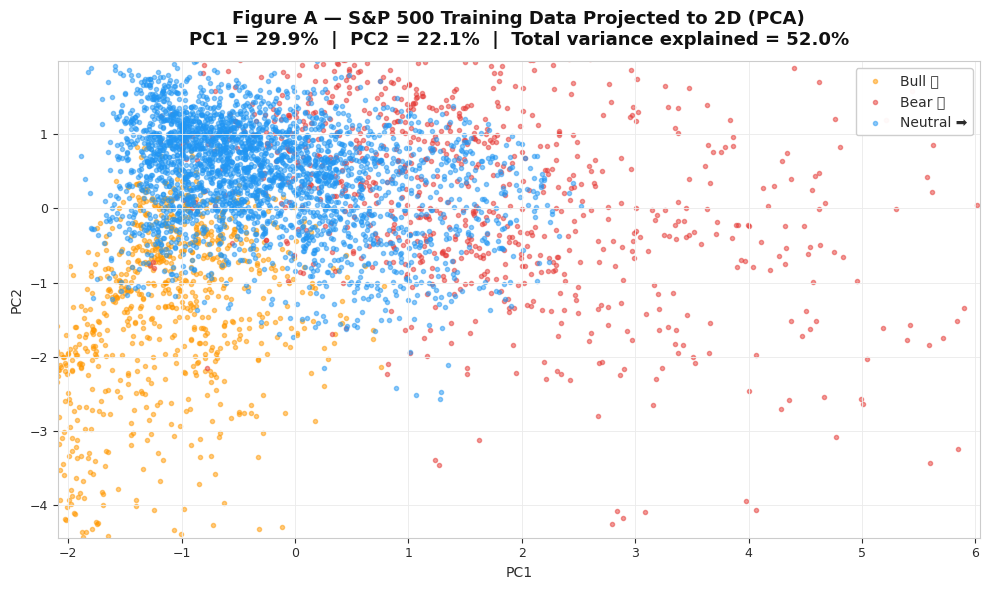

✅  fig_A_raw_data_2d.png


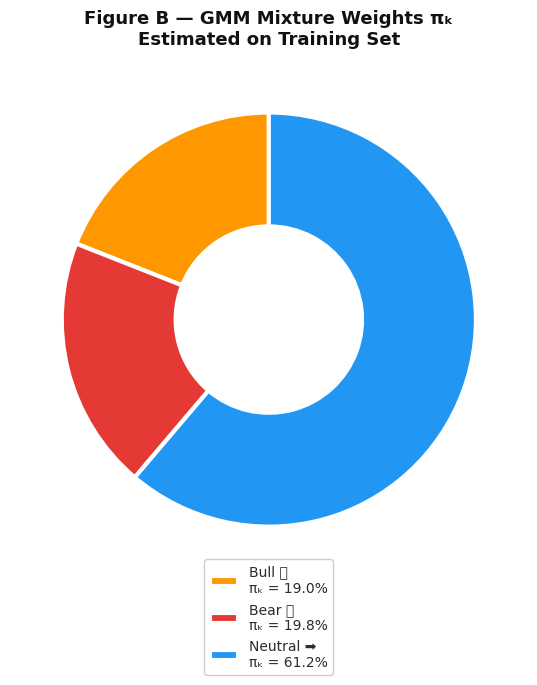

✅  fig_B_mixture_weights.png


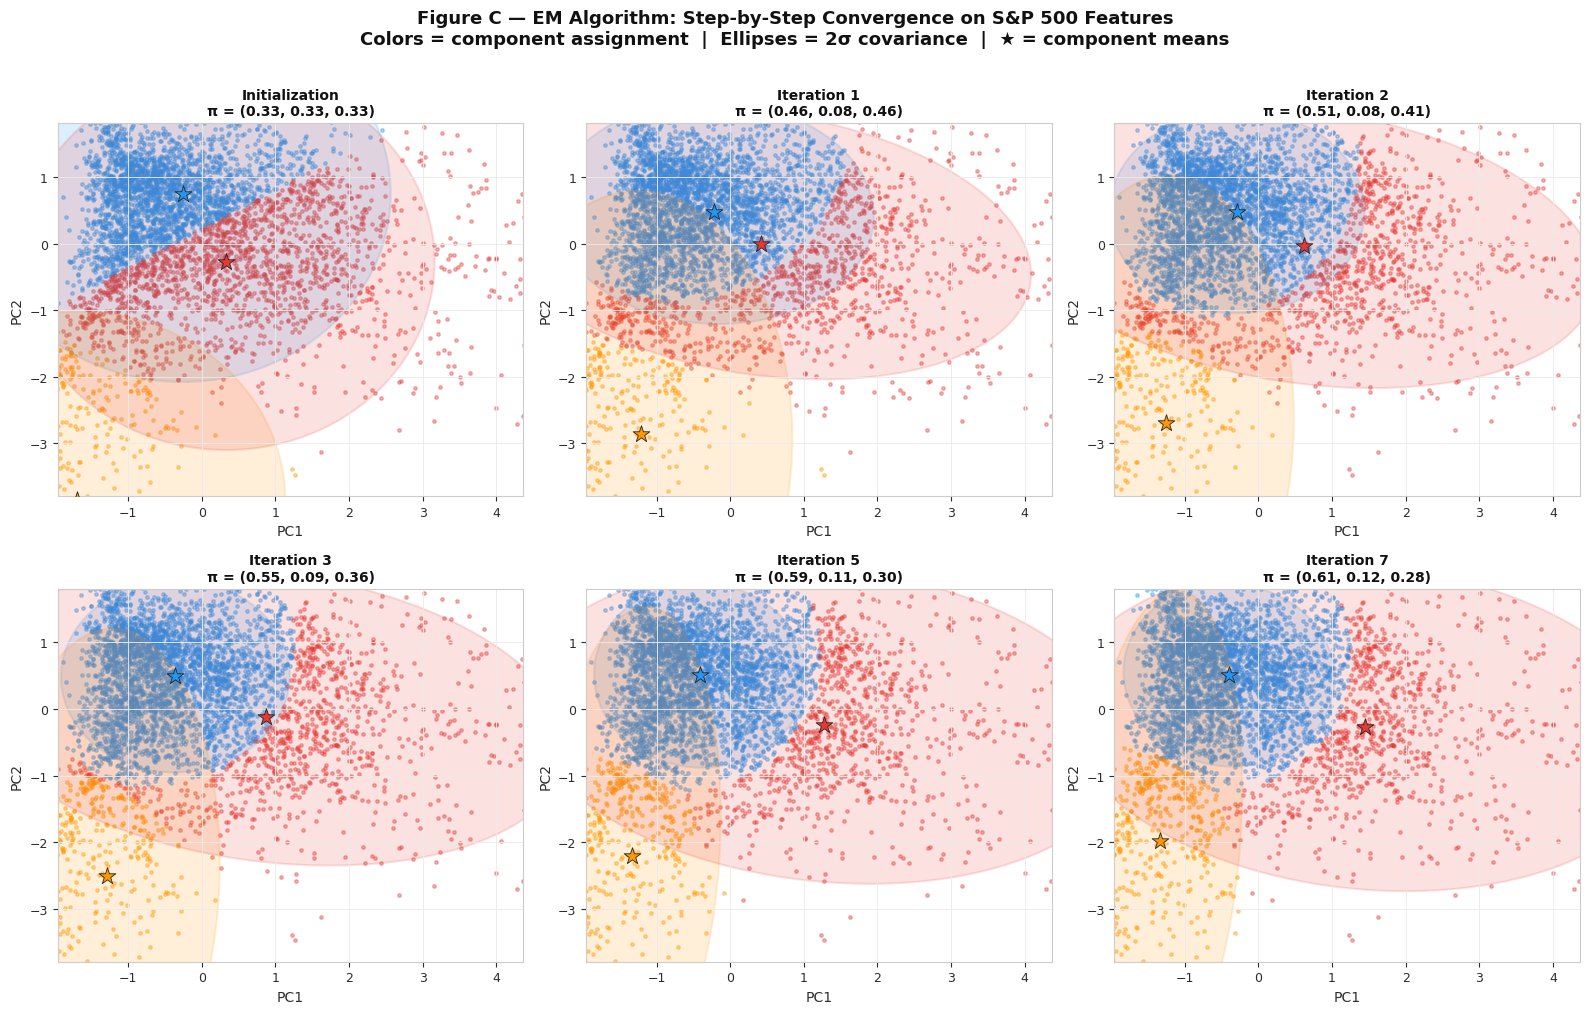

✅  fig_C_em_iterations.png


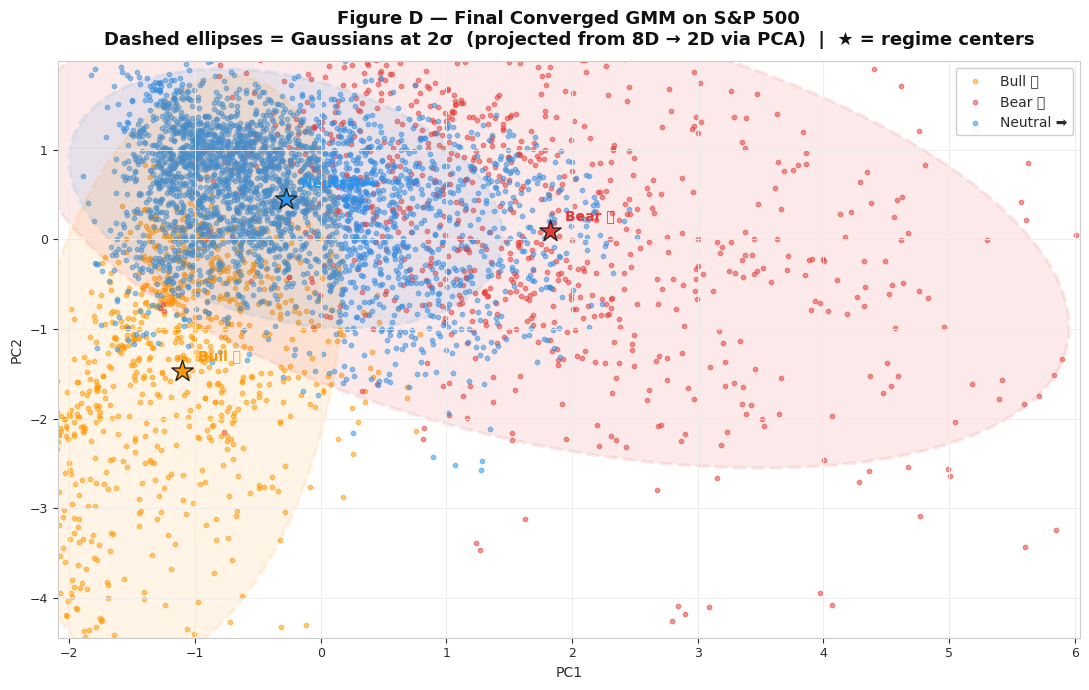

✅  fig_D_gmm_final_result.png


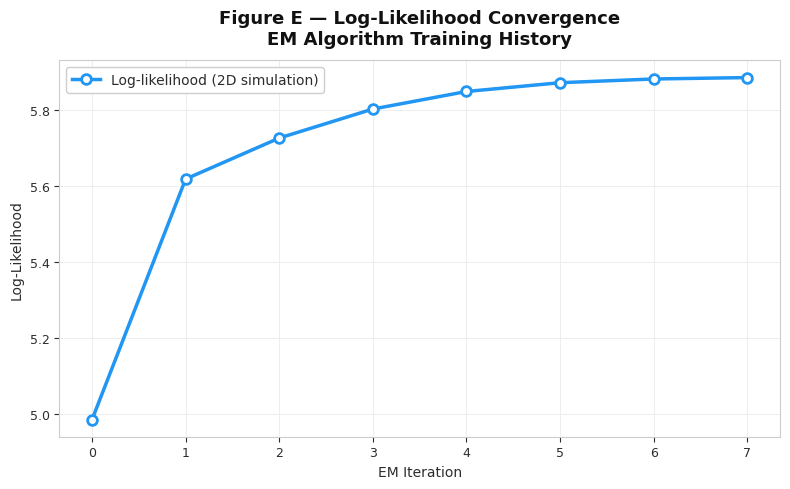

✅  fig_E_loglikelihood_convergence.png


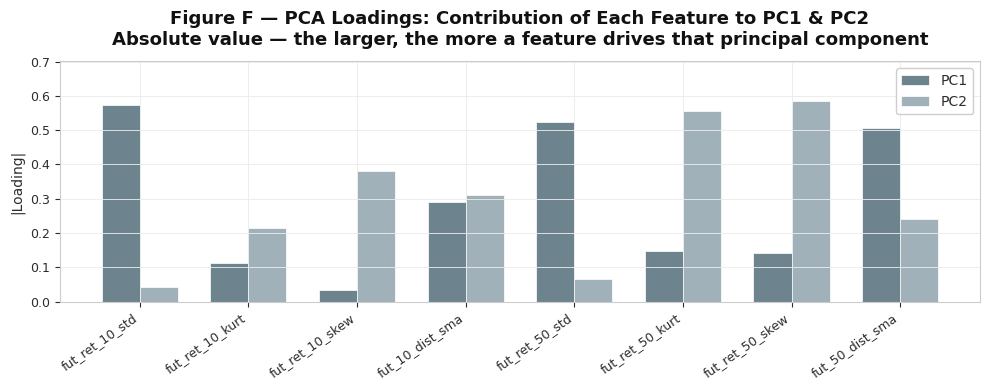

✅  fig_F_pca_loadings.png

🎉  All 6 figures saved successfully.


In [232]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal


BG   = 'white'
GRID = '#EBEBEB'
TC   = '#2c2c2c'
SPINE = '#CCCCCC'

REGIME_COLORS = {'bull': '#FF9800', 'bear': '#E53935', 'neutral': '#2196F3'}
REGIME_NAMES  = {'bull': 'Bull 📈',  'bear': 'Bear 📉',  'neutral': 'Neutral ➡️'}
CLUSTER_COLORS = ['#2196F3', '#FF9800', '#E53935']   # for simulated EM steps

TITLE_KW = dict(fontsize=13, fontweight='bold', color='#111111', pad=12)
LABEL_KW = dict(color=TC, fontsize=10)

LEGEND_KW = dict(facecolor='white', edgecolor=SPINE, labelcolor=TC,
                 fontsize=10, framealpha=0.95)

def style_ax(ax):
    """Consistent white-theme styling."""
    ax.set_facecolor(BG)
    ax.tick_params(axis='both', colors=TC, labelsize=9,
                   labelcolor=TC)          # explicit labelcolor, never inherits white
    for spine in ax.spines.values():
        spine.set_color(SPINE)
    ax.grid(True, color=GRID, alpha=0.9, linewidth=0.7)


# 1. PCA 2D PROJECTION  — fit on X_train_scaled, transform both sets
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

var = pca.explained_variance_ratio_
print(f"\n📐 PCA explained variance:  PC1 = {var[0]*100:.1f}%  |  "
      f"PC2 = {var[1]*100:.1f}%  |  Total = {sum(var)*100:.1f}%")
print(f"   Features used: {list(X_train_scaled.columns)}\n")

# Regime labels aligned with df index order
regime_labels = np.array([cluster_map.get(c, 'neutral') for c in df['cluster'].values])
n_train       = len(X_train_scaled)
labels_train  = regime_labels[:n_train]
labels_test   = regime_labels[n_train:]

# Map each GMM component index → regime name
gmm_to_regime = {int(k): v for k, v in cluster_map.items()}


# 2. HELPER FUNCTIONS
def get_ellipse_params(mean, cov, pca_obj, n_std=2.0):
    """
    Project a p-dim Gaussian (mean, cov) into 2D via PCA.
    Returns (mean_2d, width, height, angle_degrees).
    """
    mean_2d = pca_obj.transform(mean.reshape(1, -1))[0]
    W       = pca_obj.components_        # (2, p)
    cov_2d  = W @ cov @ W.T             # (2, 2)

    vals, vecs = np.linalg.eigh(cov_2d)
    order      = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    angle  = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width  = 2 * n_std * np.sqrt(max(vals[0], 1e-9))
    height = 2 * n_std * np.sqrt(max(vals[1], 1e-9))
    return mean_2d, width, height, angle


def draw_ellipse(ax, mean, cov, color, alpha=0.18, n_std=2.0, lw=1.8):
    """Draw a 2D confidence ellipse at n_std σ."""
    vals, vecs = np.linalg.eigh(cov)
    order      = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width  = 2 * n_std * np.sqrt(max(vals[0], 1e-9))
    height = 2 * n_std * np.sqrt(max(vals[1], 1e-9))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor=color, alpha=alpha,
                  edgecolor=color, linewidth=lw)
    ax.add_patch(ell)


def xlim_ylim(data, p_lo=1, p_hi=99):
    """Return tight (xmin,xmax), (ymin,ymax) based on percentiles."""
    return ((np.percentile(data[:, 0], p_lo), np.percentile(data[:, 0], p_hi)),
            (np.percentile(data[:, 1], p_lo), np.percentile(data[:, 1], p_hi)))


# 3. EM SIMULATION FOR STEP-BY-STEP VISUALIZATION

def simulate_em_steps(X_2d, n_components=3, n_iter=8, seed=42):
    """
    Runs a from-scratch GMM EM on 2D data and records parameter history.
    Used purely for visualizing the convergence process.
    """
    rng     = np.random.RandomState(seed)
    history = []

    idx   = rng.choice(len(X_2d), n_components, replace=False)
    means = X_2d[idx].copy()
    covs  = np.array([np.eye(2) * 2.0 for _ in range(n_components)])
    pis   = np.ones(n_components) / n_components

    for it in range(n_iter):
        # E-STEP
        resp = np.zeros((len(X_2d), n_components))
        for k in range(n_components):
            try:
                resp[:, k] = pis[k] * multivariate_normal.pdf(
                    X_2d, means[k], covs[k])
            except Exception:
                resp[:, k] = pis[k] * 1e-10

        denom = resp.sum(axis=1, keepdims=True)
        denom = np.where(denom == 0, 1e-10, denom)
        resp /= denom

        history.append({
            'iter' : it,
            'means': means.copy(),
            'covs' : covs.copy(),
            'pis'  : pis.copy(),
            'resp' : resp.copy(),
        })

        # M-STEP 
        Nk = resp.sum(axis=0)
        for k in range(n_components):
            if Nk[k] > 1e-6:
                means[k] = (resp[:, k:k+1] * X_2d).sum(axis=0) / Nk[k]
                diff      = X_2d - means[k]
                covs[k]   = (resp[:, k:k+1] * diff).T @ diff / Nk[k]
                covs[k]  += np.eye(2) * 1e-4   # numerical regularization
        pis = Nk / len(X_2d)

    return history


history       = simulate_em_steps(X_train_2d, n_components=3, n_iter=8)
iters_to_show = [0, 1, 2, 3, 5, 7]
xl, yl        = xlim_ylim(X_train_2d)



# FIGURE A — Raw 2D PCA Scatter (starting point of EM)
fig_a, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_title(
    'Figure A — S&P 500 Training Data Projected to 2D (PCA)\n'
    f'PC1 = {var[0]*100:.1f}%  |  PC2 = {var[1]*100:.1f}%  |  '
    f'Total variance explained = {sum(var)*100:.1f}%',
    **TITLE_KW)

for regime, color in REGIME_COLORS.items():
    mask = labels_train == regime
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=color, s=9, alpha=0.50, label=REGIME_NAMES[regime], rasterized=True)

ax.set_xlabel('PC1', **LABEL_KW)
ax.set_ylabel('PC2', **LABEL_KW)
style_ax(ax)
ax.set_xlim(*xl); ax.set_ylim(*yl)
ax.legend(loc='upper right', **LEGEND_KW)
fig_a.tight_layout()
fig_a.savefig('fig_A_raw_data_2d.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_A_raw_data_2d.png")


# FIGURE B — Mixture Weights πₖ  (donut chart)
fig_b, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
ax.set_facecolor(BG)
ax.set_title('Figure B — GMM Mixture Weights πₖ\nEstimated on Training Set', **TITLE_KW)

counts     = {r: (labels_train == r).sum() for r in REGIME_COLORS}
sizes      = list(counts.values())
colors_pie = list(REGIME_COLORS.values())
labels_pie = [f"{REGIME_NAMES[r]}\nπₖ = {s / sum(sizes) * 100:.1f}%"
              for r, s in counts.items()]

wedges, _ = ax.pie(sizes, colors=colors_pie, startangle=90,
                   wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3))
ax.legend(wedges, labels_pie, loc='lower center',
          bbox_to_anchor=(0.5, -0.20), ncol=1, **LEGEND_KW)
fig_b.tight_layout()
fig_b.savefig('fig_B_mixture_weights.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_B_mixture_weights.png")


# FIGURE C — EM Convergence Steps  (2 × 3 grid)

fig_c, axes_c = plt.subplots(2, 3, figsize=(16, 10), facecolor=BG)
fig_c.suptitle(
    'Figure C — EM Algorithm: Step-by-Step Convergence on S&P 500 Features\n'
    'Colors = component assignment  |  Ellipses = 2σ covariance  |  ★ = component means',
    fontsize=13, fontweight='bold', color='#111111', y=1.01)

for idx_plot, it in enumerate(iters_to_show):
    row_i = idx_plot // 3
    col_i = idx_plot  % 3
    ax    = axes_c[row_i, col_i]
    h     = history[it]

    assignments = h['resp'].argmax(axis=1)
    for k in range(3):
        mask = assignments == k
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   c=CLUSTER_COLORS[k], s=6, alpha=0.38, rasterized=True)
    for k in range(3):
        draw_ellipse(ax, h['means'][k], h['covs'][k],
                     color=CLUSTER_COLORS[k], alpha=0.15, n_std=2.0, lw=1.5)
        ax.scatter(*h['means'][k], c=CLUSTER_COLORS[k],
                   s=160, marker='*', zorder=6, edgecolors='#222222', linewidths=0.6)

    label = "Initialization" if it == 0 else f"Iteration {it}"
    ax.set_title(f'{label}\nπ = ({h["pis"][0]:.2f}, {h["pis"][1]:.2f}, {h["pis"][2]:.2f})',
                 fontsize=10, fontweight='bold', color='#111111', pad=6)
    ax.set_xlabel('PC1', **LABEL_KW)
    ax.set_ylabel('PC2', **LABEL_KW)
    style_ax(ax)
    xl2, yl2 = xlim_ylim(X_train_2d, p_lo=2, p_hi=98)
    ax.set_xlim(*xl2); ax.set_ylim(*yl2)

fig_c.tight_layout()
fig_c.savefig('fig_C_em_iterations.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_C_em_iterations.png")


# FIGURE D — Final Converged GMM  (true sklearn model projected into 2D)
fig_d, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_title(
    'Figure D — Final Converged GMM on S&P 500\n'
    'Dashed ellipses = Gaussians at 2σ  (projected from 8D → 2D via PCA)  |  ★ = regime centers',
    **TITLE_KW)

for regime, color in REGIME_COLORS.items():
    mask = labels_train == regime
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=color, s=10, alpha=0.50, label=REGIME_NAMES[regime], rasterized=True)

for k in range(model.n_components):
    regime  = gmm_to_regime.get(k, 'neutral')
    color   = REGIME_COLORS[regime]
    mean_2d, w, h_ell, angle = get_ellipse_params(
        model.means_[k], model.covariances_[k], pca, n_std=2.0)

    ell = Ellipse(xy=mean_2d, width=w, height=h_ell, angle=angle,
                  facecolor=color, alpha=0.10,
                  edgecolor=color, linewidth=2.5, linestyle='--')
    ax.add_patch(ell)
    ax.scatter(*mean_2d, c=color, s=260, marker='*',
               zorder=7, edgecolors='#222222', linewidths=1.0)
    ax.annotate(REGIME_NAMES[regime], xy=mean_2d,
                xytext=(mean_2d[0] + 0.12, mean_2d[1] + 0.12),
                color=color, fontsize=10, fontweight='bold')

ax.set_xlabel('PC1', **LABEL_KW)
ax.set_ylabel('PC2', **LABEL_KW)
style_ax(ax)
ax.set_xlim(*xl); ax.set_ylim(*yl)
ax.legend(loc='upper right', **LEGEND_KW)
fig_d.tight_layout()
fig_d.savefig('fig_D_gmm_final_result.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_D_gmm_final_result.png")


# FIGURE E — Log-Likelihood Convergence Curve
fig_e, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_title('Figure E — Log-Likelihood Convergence\nEM Algorithm Training History', **TITLE_KW)

# Try to use sklearn's internal monitor first (warm_start or verbose mode stores it)
try:
    ll_history = model.monitor_.history
    iters_ll   = list(range(len(ll_history)))
    ax.plot(iters_ll, ll_history,
            color='#2196F3', linewidth=2.5,
            marker='o', markersize=7, markerfacecolor='white',
            markeredgecolor='#2196F3', markeredgewidth=2,
            label='Log-likelihood per EM iteration')
    ax.axhline(y=ll_history[-1], color='#FF9800', linewidth=1.5,
               linestyle='--', alpha=0.85,
               label=f'Convergence  ({ll_history[-1]:.1f})')
    ax.legend(**LEGEND_KW)
except Exception:
    # Fallback: compute log-likelihood from the 2D simulation history
    ll_vals = []
    for h in history:
        ll = 0.0
        for k in range(3):
            try:
                ll += h['pis'][k] * multivariate_normal.pdf(
                    X_train_2d, h['means'][k], h['covs'][k]).sum()
            except Exception:
                pass
        ll_vals.append(np.log(max(ll, 1e-10)))
    ax.plot(ll_vals, color='#2196F3', linewidth=2.5,
            marker='o', markersize=7, markerfacecolor='white',
            markeredgecolor='#2196F3', markeredgewidth=2,
            label='Log-likelihood (2D simulation)')
    ax.legend(**LEGEND_KW)

ax.set_xlabel('EM Iteration', **LABEL_KW)
ax.set_ylabel('Log-Likelihood', **LABEL_KW)
style_ax(ax)
fig_e.tight_layout()
fig_e.savefig('fig_E_loglikelihood_convergence.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_E_loglikelihood_convergence.png")

# FIGURE F — Feature Importance in PCA  (loadings heatmap)
fig_f, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.set_title(
    'Figure F — PCA Loadings: Contribution of Each Feature to PC1 & PC2\n'
    'Absolute value — the larger, the more a feature drives that principal component',
    **TITLE_KW)

feature_names = list(X_train_scaled.columns)
loadings      = pca.components_          # shape (2, n_features)

x     = np.arange(len(feature_names))
width = 0.35

bars1 = ax.bar(x - width/2, np.abs(loadings[0]), width,
               label='PC1', color='#546E7A', alpha=0.85, edgecolor='white', linewidth=0.6)
bars2 = ax.bar(x + width/2, np.abs(loadings[1]), width,
               label='PC2', color='#90A4AE', alpha=0.85, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=35, ha='right', fontsize=8.5, color=TC)
ax.set_ylabel('|Loading|', **LABEL_KW)
style_ax(ax)
ax.legend(**LEGEND_KW)
ax.set_ylim(0, np.abs(loadings).max() * 1.2)
fig_f.tight_layout()
fig_f.savefig('fig_F_pca_loadings.png', dpi=150, bbox_inches='tight',
              facecolor=BG, edgecolor='none')
plt.show()
print("✅  fig_F_pca_loadings.png")

print("\n🎉  All 6 figures saved successfully.")